# Seattle Permit Predictor — Quantile Regression Model
*Predicting Optimistic / Typical / Pessimistic Review Timelines*

**Goal:** For a given permit submission, predict three timeline estimates:
- **Optimistic (10th percentile)** — faster than 90% of similar permits
- **Typical (50th percentile / median)** — the most likely outcome
- **Pessimistic (90th percentile)** — slower than 90% of similar permits

Output format: `X.X months (Y days)` for each estimate.

**Why quantile regression over point prediction:**  
Permit review time is inherently uncertain. Rather than predicting a single number with a wide confidence interval, quantile regression directly models the distribution of outcomes — giving applicants an honest range that reflects real-world variability.

**Model:** LightGBM with quantile loss (`alpha` = 0.10, 0.50, 0.90) — three separate models trained on the same feature set, one per quantile. LightGBM is chosen because it handles nulls natively (important for comment features with 95% null rate), trains quickly, and produced the best performance in the feature selection analysis (OOF R² = 0.4359).

**Feature set (from FeatureSelection.ipynb):**
- Categorical: `permittypedesc`, `permitclass`, `zone_family`, `review_complexity_max`
- Numeric: `latitude`, `longitude`, `log_housingunitsadded`, `app_year`, `app_month`
- Comment (optional): `comment_n_distinct_cycles`, `comment_n_rows`

**Note:** `estprojectcost` is excluded per liaison guidance — not known at submission time.

## 0. Install & Import

In [1]:
import sys
!{sys.executable} -m pip install lightgbm shap --quiet
print('Dependencies ready.')

Dependencies ready.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: C:\Users\flori\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import joblib
import warnings
import datetime
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import lightgbm as lgb
import shap

RANDOM_STATE = 42
DATA_DIR     = Path(r'C:\Users\flori\Documents\GitHub\CSB425-City-of-Seattle-Permit-Predictor\data')
OUTPUT_DIR   = Path(r'C:\Users\flori\Documents\GitHub\CSB425-City-of-Seattle-Permit-Predictor\output')
plt.style.use('seaborn-v0_8-whitegrid')
print('Libraries loaded.')

Libraries loaded.


## 1. Load & Join Data

In [3]:
df = pd.read_csv(DATA_DIR / 'master_dataset.csv')
print(f'Master dataset   : {len(df):,} rows')

comment_features = pd.read_csv(OUTPUT_DIR / 'comment_features.csv')
df = df.merge(comment_features, on='permitnum', how='left')

has_comments = df['comment_n_rows'].notna().sum()
print(f'After join       : {len(df):,} rows')
print(f'  With comments  : {has_comments:,} ({has_comments/len(df)*100:.1f}%)')
print(f'\nReview time distribution (days):')
print(df['totaldaysplanreview'].describe().round(1))

Master dataset   : 14,201 rows
After join       : 14,201 rows
  With comments  : 665 (4.7%)

Review time distribution (days):
count    14201.0
mean       153.9
std        155.0
min          3.0
25%         52.0
50%        103.0
75%        202.0
max       1094.0
Name: totaldaysplanreview, dtype: float64


## 2. Feature Selection & Preprocessing

Feature set from `FeatureSelection.ipynb` — 11 features selected via two-stage mutual information + SHAP analysis.

In [4]:
CAT_FEATURES = [
    'permittypedesc',
    'permitclass',
    'zone_family',
    'review_complexity_max',
]

NUM_FEATURES = [
    'latitude',
    'longitude',
    'log_housingunitsadded',
    'app_year',
    'app_month',
    'comment_n_distinct_cycles',
    'comment_n_rows',
]

ALL_FEATURES = CAT_FEATURES + NUM_FEATURES
TARGET       = 'log_target'  # log(1 + totaldaysplanreview)

for col in CAT_FEATURES:
    df[col] = df[col].fillna('Unknown').astype(str)

X = df[ALL_FEATURES].copy()
y = df[TARGET].copy()

print('Feature set:')
print(f'  Categorical ({len(CAT_FEATURES)}) : {CAT_FEATURES}')
print(f'  Numeric ({len(NUM_FEATURES)})     : {NUM_FEATURES}')
print(f'\nX shape: {X.shape} | y shape: {y.shape}')
print(f'\nNull counts:')
print(X.isnull().sum())

Feature set:
  Categorical (4) : ['permittypedesc', 'permitclass', 'zone_family', 'review_complexity_max']
  Numeric (7)     : ['latitude', 'longitude', 'log_housingunitsadded', 'app_year', 'app_month', 'comment_n_distinct_cycles', 'comment_n_rows']

X shape: (14201, 11) | y shape: (14201,)

Null counts:
permittypedesc                   0
permitclass                      0
zone_family                      0
review_complexity_max            0
latitude                        19
longitude                       19
log_housingunitsadded          237
app_year                         0
app_month                        0
comment_n_distinct_cycles    13536
comment_n_rows               13536
dtype: int64


In [5]:
# OrdinalEncoder for categoricals — LightGBM needs numeric input
# Numerics passed through — LightGBM handles nulls natively
cat_pipe = Pipeline([
    ('encode', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor = ColumnTransformer([
    ('cat', cat_pipe,       CAT_FEATURES),
    ('num', 'passthrough',  NUM_FEATURES),
], remainder='drop')

# Fit preprocessor on full dataset so encoder categories are stable
preprocessor.fit(X)
X_enc = preprocessor.transform(X)
feature_names_enc = CAT_FEATURES + NUM_FEATURES

print('Preprocessor fitted.')
print(f'Encoded shape: {X_enc.shape}')

Preprocessor fitted.
Encoded shape: (14201, 11)


## 3. Quantile Model — 5-Fold Cross Validation

Three LightGBM models are trained — one per quantile (10th, 50th, 90th). Each uses `objective='quantile'` with the corresponding `alpha`. All three share the same hyperparameters and cross-validation folds for direct comparability.

Evaluation metrics:
- **Pinball loss** (quantile-specific loss function) — lower is better
- **Coverage rate** — what fraction of actual values fall within the 10th–90th interval (target: ~80%)
- **Median MAE in days** — how far off the 50th percentile prediction is on average

In [6]:
QUANTILES = {
    'optimistic':  0.10,
    'typical':     0.50,
    'pessimistic': 0.90,
}

LGB_PARAMS = dict(
    objective        = 'quantile',
    n_estimators     = 500,
    learning_rate    = 0.03,
    max_depth        = 6,
    num_leaves       = 31,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_samples= 20,
    random_state     = RANDOM_STATE,
    n_jobs           = -1,
    verbose          = -1,
)

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Store OOF predictions for all three quantiles
oof = {name: np.zeros(len(y)) for name in QUANTILES}
fold_metrics = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_enc), 1):
    X_train, X_val = X_enc[train_idx], X_enc[val_idx]
    y_train, y_val = y.iloc[train_idx].values, y.iloc[val_idx].values

    fold_result = {'fold': fold}

    for name, alpha in QUANTILES.items():
        model = lgb.LGBMRegressor(**{**LGB_PARAMS, 'alpha': alpha})
        model.fit(X_train, y_train)
        preds_log = model.predict(X_val)
        oof[name][val_idx] = preds_log

        # Pinball loss
        errors = y_val - preds_log
        pinball = np.mean(np.where(errors >= 0, alpha * errors, (alpha - 1) * errors))
        fold_result[f'pinball_{name}'] = pinball

    # Coverage: fraction of actuals within [optimistic, pessimistic]
    coverage = np.mean(
        (y_val >= oof['optimistic'][val_idx]) &
        (y_val <= oof['pessimistic'][val_idx])
    )
    fold_result['coverage'] = coverage

    # Median MAE in days
    mae_days = mean_absolute_error(
        np.expm1(y_val),
        np.expm1(oof['typical'][val_idx])
    )
    fold_result['mae_days_typical'] = mae_days

    fold_metrics.append(fold_result)
    print(f'Fold {fold} | Coverage={coverage:.3f} | MAE(typical, days)={mae_days:.1f} | '
          f'Pinball(opt={fold_result["pinball_optimistic"]:.4f}, '
          f'typ={fold_result["pinball_typical"]:.4f}, '
          f'pes={fold_result["pinball_pessimistic"]:.4f})')

metrics_df = pd.DataFrame(fold_metrics)
print('\n--- 5-Fold Cross Validation Summary ---')
print(metrics_df.drop('fold', axis=1).describe().loc[['mean','std']].round(4))

Fold 1 | Coverage=0.774 | MAE(typical, days)=69.9 | Pinball(opt=0.1164, typ=0.2675, pes=0.1227)
Fold 2 | Coverage=0.758 | MAE(typical, days)=73.6 | Pinball(opt=0.1151, typ=0.2686, pes=0.1271)
Fold 3 | Coverage=0.770 | MAE(typical, days)=73.0 | Pinball(opt=0.1161, typ=0.2682, pes=0.1264)
Fold 4 | Coverage=0.761 | MAE(typical, days)=72.0 | Pinball(opt=0.1144, typ=0.2658, pes=0.1234)
Fold 5 | Coverage=0.770 | MAE(typical, days)=69.6 | Pinball(opt=0.1177, typ=0.2684, pes=0.1250)

--- 5-Fold Cross Validation Summary ---
      pinball_optimistic  pinball_typical  pinball_pessimistic  coverage  \
mean              0.1159           0.2677               0.1249    0.7667   
std               0.0013           0.0011               0.0019    0.0067   

      mae_days_typical  
mean           71.6279  
std             1.8033  


## 4. Hyperparameter Tuning

Grid search over key LightGBM parameters. Tuned on the typical (median) quantile since it has the most predictive signal. Best params are then applied to all three quantile models.

In [7]:
from sklearn.base import BaseEstimator, RegressorMixin

# Wrap LGBMRegressor in sklearn-compatible class for GridSearchCV
class LGBMQuantileRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, n_estimators=500, learning_rate=0.03, max_depth=6,
                 num_leaves=31, subsample=0.8, colsample_bytree=0.8,
                 min_child_samples=20, alpha=0.5):
        self.n_estimators     = n_estimators
        self.learning_rate    = learning_rate
        self.max_depth        = max_depth
        self.num_leaves       = num_leaves
        self.subsample        = subsample
        self.colsample_bytree = colsample_bytree
        self.min_child_samples= min_child_samples
        self.alpha            = alpha

    def fit(self, X, y):
        self.model_ = lgb.LGBMRegressor(
            objective='quantile', alpha=self.alpha,
            n_estimators=self.n_estimators, learning_rate=self.learning_rate,
            max_depth=self.max_depth, num_leaves=self.num_leaves,
            subsample=self.subsample, colsample_bytree=self.colsample_bytree,
            min_child_samples=self.min_child_samples,
            random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
        )
        self.model_.fit(X, y)
        return self

    def predict(self, X):
        return self.model_.predict(X)


param_grid = {
    'n_estimators':      [300, 500],
    'learning_rate':     [0.03, 0.05],
    'max_depth':         [4, 6],
    'num_leaves':        [15, 31],
    'min_child_samples': [10, 20],
}

def pinball_scorer(estimator, X, y, alpha=0.5):
    preds  = estimator.predict(X)
    errors = y - preds
    return -np.mean(np.where(errors >= 0, alpha * errors, (alpha - 1) * errors))

from sklearn.metrics import make_scorer
median_pinball = make_scorer(lambda est, X, y: pinball_scorer(est, X, y, alpha=0.5))

grid_search = GridSearchCV(
    LGBMQuantileRegressor(alpha=0.5),
    param_grid,
    cv=kf,
    scoring=median_pinball,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_enc, y.values)

best_params = grid_search.best_params_
print('\nBest parameters:')
for k, v in best_params.items():
    print(f'  {k}: {v}')
print(f'\nBest median pinball score: {-grid_search.best_score_:.4f}')

Fitting 5 folds for each of 32 candidates, totalling 160 fits

Best parameters:
  learning_rate: 0.03
  max_depth: 4
  min_child_samples: 10
  n_estimators: 300
  num_leaves: 15

Best median pinball score: nan


## 5. Tuned Quantile Models — Final 5-Fold CV

In [8]:
tuned_params = {
    **LGB_PARAMS,
    **best_params
}

# Train final models — one per quantile
oof_tuned = {name: np.zeros(len(y)) for name in QUANTILES}
tuned_fold_metrics = []
tuned_models = {}  # store fitted models for full-dataset refit

for fold, (train_idx, val_idx) in enumerate(kf.split(X_enc), 1):
    X_train, X_val = X_enc[train_idx], X_enc[val_idx]
    y_train, y_val = y.iloc[train_idx].values, y.iloc[val_idx].values

    fold_result = {'fold': fold}

    for name, alpha in QUANTILES.items():
        model = lgb.LGBMRegressor(**{**tuned_params, 'alpha': alpha})
        model.fit(X_train, y_train)
        preds_log = model.predict(X_val)
        oof_tuned[name][val_idx] = preds_log

        errors  = y_val - preds_log
        pinball = np.mean(np.where(errors >= 0, alpha * errors, (alpha - 1) * errors))
        fold_result[f'pinball_{name}'] = pinball

    coverage = np.mean(
        (y_val >= oof_tuned['optimistic'][val_idx]) &
        (y_val <= oof_tuned['pessimistic'][val_idx])
    )
    mae_days = mean_absolute_error(
        np.expm1(y_val),
        np.expm1(oof_tuned['typical'][val_idx])
    )
    fold_result['coverage']         = coverage
    fold_result['mae_days_typical'] = mae_days
    tuned_fold_metrics.append(fold_result)

    print(f'Fold {fold} | Coverage={coverage:.3f} | MAE(typical, days)={mae_days:.1f}')

tuned_metrics_df = pd.DataFrame(tuned_fold_metrics)
print('\n--- Tuned Model 5-Fold CV Summary ---')
print(tuned_metrics_df.drop('fold', axis=1).describe().loc[['mean','std']].round(4))

# Refit all three quantile models on full dataset for inference
print('\nRefitting on full dataset...')
for name, alpha in QUANTILES.items():
    m = lgb.LGBMRegressor(**{**tuned_params, 'alpha': alpha})
    m.fit(X_enc, y.values)
    tuned_models[name] = m
    print(f'  {name} model fitted.')

Fold 1 | Coverage=0.791 | MAE(typical, days)=70.9
Fold 2 | Coverage=0.785 | MAE(typical, days)=74.9
Fold 3 | Coverage=0.792 | MAE(typical, days)=74.1
Fold 4 | Coverage=0.786 | MAE(typical, days)=73.6
Fold 5 | Coverage=0.784 | MAE(typical, days)=71.1

--- Tuned Model 5-Fold CV Summary ---
      pinball_optimistic  pinball_typical  pinball_pessimistic  coverage  \
mean              0.1171           0.2716               0.1262    0.7875   
std               0.0014           0.0012               0.0013    0.0039   

      mae_days_typical  
mean           72.9330  
std             1.8068  

Refitting on full dataset...
  optimistic model fitted.
  typical model fitted.
  pessimistic model fitted.


## 6. Evaluation Plots

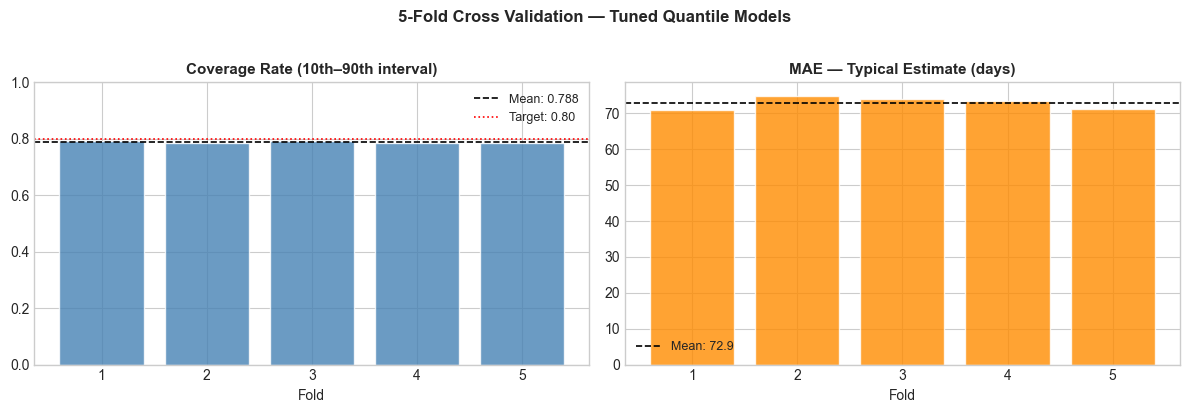

Saved: cv_metrics_quantile.png


In [9]:
# --- Per-fold coverage and MAE bar charts ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(tuned_metrics_df['fold'], tuned_metrics_df['coverage'],
            color='steelblue', alpha=0.8, edgecolor='white')
axes[0].axhline(tuned_metrics_df['coverage'].mean(), color='black', linestyle='--',
                linewidth=1.2, label=f"Mean: {tuned_metrics_df['coverage'].mean():.3f}")
axes[0].axhline(0.80, color='red', linestyle=':', linewidth=1.2, label='Target: 0.80')
axes[0].set_title('Coverage Rate (10th–90th interval)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Fold')
axes[0].set_xticks(tuned_metrics_df['fold'])
axes[0].set_ylim(0, 1)
axes[0].legend(fontsize=9)

axes[1].bar(tuned_metrics_df['fold'], tuned_metrics_df['mae_days_typical'],
            color='darkorange', alpha=0.8, edgecolor='white')
axes[1].axhline(tuned_metrics_df['mae_days_typical'].mean(), color='black', linestyle='--',
                linewidth=1.2, label=f"Mean: {tuned_metrics_df['mae_days_typical'].mean():.1f}")
axes[1].set_title('MAE — Typical Estimate (days)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Fold')
axes[1].set_xticks(tuned_metrics_df['fold'])
axes[1].legend(fontsize=9)

plt.suptitle('5-Fold Cross Validation — Tuned Quantile Models', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cv_metrics_quantile.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: cv_metrics_quantile.png')

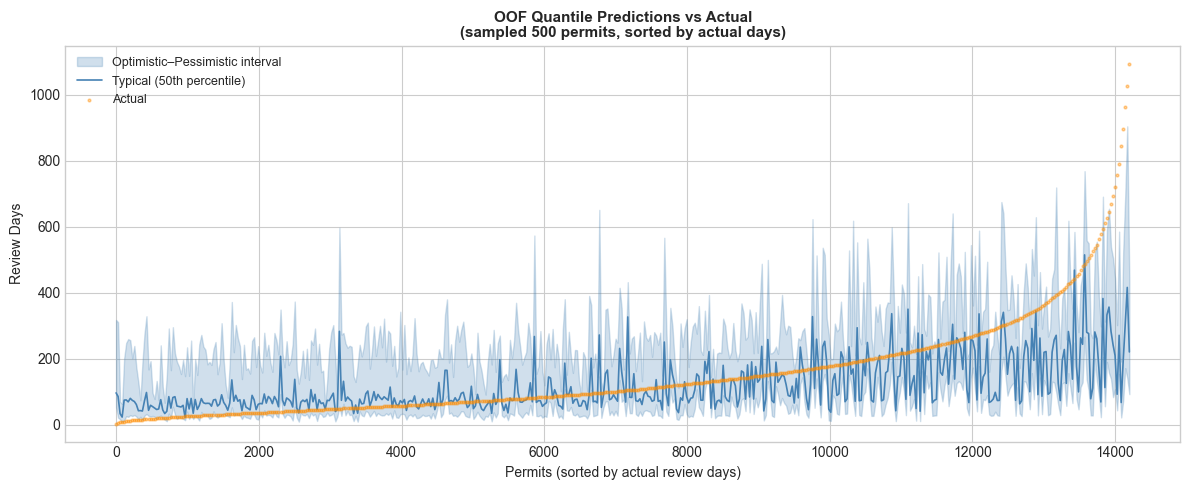

Saved: oof_quantile_intervals.png


In [10]:
# --- OOF predicted intervals vs actual ---
actual_days = np.expm1(y.values)
opt_days    = np.expm1(oof_tuned['optimistic'])
typ_days    = np.expm1(oof_tuned['typical'])
pes_days    = np.expm1(oof_tuned['pessimistic'])

# Sort by actual for clean interval plot
sort_idx = np.argsort(actual_days)
x_plot   = np.arange(len(sort_idx))

# Sample 500 points for readability
sample = np.linspace(0, len(sort_idx)-1, 500).astype(int)

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(x_plot[sample],
                opt_days[sort_idx][sample],
                pes_days[sort_idx][sample],
                alpha=0.25, color='steelblue', label='Optimistic–Pessimistic interval')
ax.plot(x_plot[sample], typ_days[sort_idx][sample],
        color='steelblue', linewidth=1.2, label='Typical (50th percentile)')
ax.scatter(x_plot[sample], actual_days[sort_idx][sample],
           s=4, color='darkorange', alpha=0.4, label='Actual', zorder=3)

ax.set_xlabel('Permits (sorted by actual review days)', fontsize=10)
ax.set_ylabel('Review Days', fontsize=10)
ax.set_title('OOF Quantile Predictions vs Actual\n(sampled 500 permits, sorted by actual days)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'oof_quantile_intervals.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: oof_quantile_intervals.png')

In [11]:
# --- Coverage by permit type ---
df_eval = df[['permittypedesc', 'permitclass', 'totaldaysplanreview']].copy()
df_eval['actual_log']   = y.values
df_eval['opt_log']      = oof_tuned['optimistic']
df_eval['typ_log']      = oof_tuned['typical']
df_eval['pes_log']      = oof_tuned['pessimistic']
df_eval['covered']      = (df_eval['actual_log'] >= df_eval['opt_log']) & \
                           (df_eval['actual_log'] <= df_eval['pes_log'])
df_eval['typ_days']     = np.expm1(df_eval['typ_log'])
df_eval['actual_days']  = df_eval['totaldaysplanreview']
df_eval['abs_error']    = (df_eval['typ_days'] - df_eval['actual_days']).abs()

coverage_by_type = df_eval.groupby('permittypedesc').agg(
    n=('covered', 'count'),
    coverage_rate=('covered', 'mean'),
    mae_days=('abs_error', 'mean'),
    actual_median=('actual_days', 'median'),
    typical_median=('typ_days', 'median'),
).round(3).sort_values('coverage_rate', ascending=False)

print('=== Coverage and Accuracy by Permit Type ===')
print(coverage_by_type.to_string())

coverage_by_class = df_eval.groupby('permitclass').agg(
    n=('covered', 'count'),
    coverage_rate=('covered', 'mean'),
    mae_days=('abs_error', 'mean'),
    actual_median=('actual_days', 'median'),
    typical_median=('typ_days', 'median'),
).round(3).sort_values('coverage_rate', ascending=False)

print('\n=== Coverage and Accuracy by Permit Class ===')
print(coverage_by_class.to_string())

=== Coverage and Accuracy by Permit Type ===
                                          n  coverage_rate  mae_days  actual_median  typical_median
permittypedesc                                                                                     
Addition/Alteration                   10101          0.791    62.164           72.0          72.745
New                                    4028          0.781    99.895          216.0         213.517
Change of Use Only - No Construction     27          0.778    55.921           97.0         103.305
Demolition                               37          0.703    60.390           62.0          96.026
Deconstruction                            1          0.000    40.606           23.0          63.606
Unknown                                   7          0.000   233.833           83.0         260.725

=== Coverage and Accuracy by Permit Class ===
                          n  coverage_rate  mae_days  actual_median  typical_median
permitclass             

## 7. SHAP Analysis — Quantile Model

SHAP values for the typical (median) model to understand which features are driving predictions.

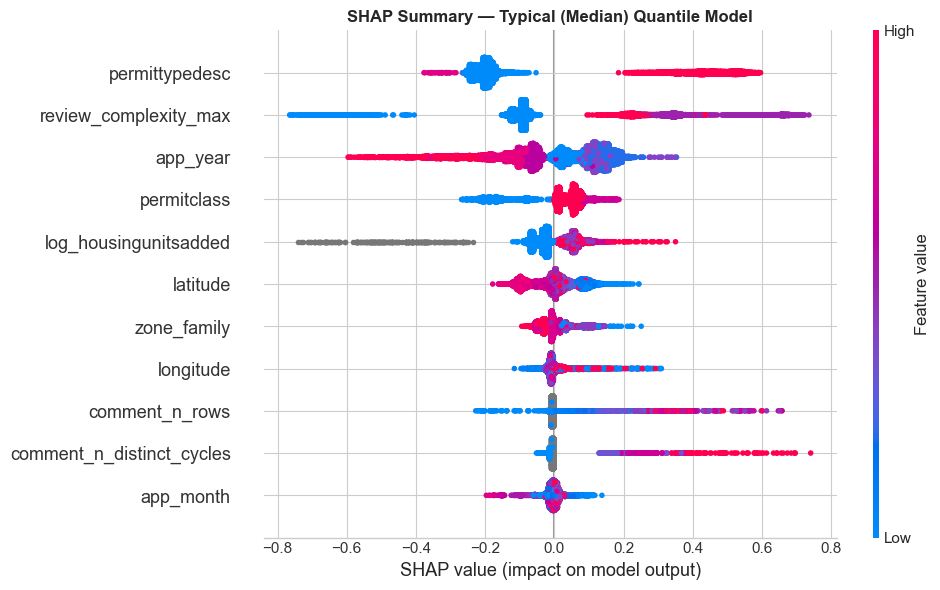

Saved: shap_quantile_typical.png


In [12]:
explainer  = shap.TreeExplainer(tuned_models['typical'])
shap_vals  = explainer.shap_values(X_enc)

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_vals,
    X_enc,
    feature_names=feature_names_enc,
    show=False,
    plot_size=None
)
plt.title('SHAP Summary — Typical (Median) Quantile Model', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'shap_quantile_typical.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_quantile_typical.png')

## 8. Save Model Weights

In [13]:
# Save all three quantile models + the fitted preprocessor together
model_bundle = {
    'preprocessor': preprocessor,
    'models':       tuned_models,         # dict: {'optimistic': lgb, 'typical': lgb, 'pessimistic': lgb}
    'feature_names': ALL_FEATURES,
    'cat_features':  CAT_FEATURES,
    'num_features':  NUM_FEATURES,
    'quantiles':     QUANTILES,
    'params':        tuned_params,
}

save_path = OUTPUT_DIR / 'ModelWeights_Quantile.joblib'
joblib.dump(model_bundle, save_path)
print(f'Model bundle saved: {save_path}')
print(f'Keys: {list(model_bundle.keys())}')

Model bundle saved: C:\Users\flori\Documents\GitHub\CSB425-City-of-Seattle-Permit-Predictor\output\ModelWeights_Quantile.joblib
Keys: ['preprocessor', 'models', 'feature_names', 'cat_features', 'num_features', 'quantiles', 'params']


## 9. Inference Function

Returns optimistic, typical, and pessimistic review time estimates in `X.X months (Y days)` format.

In [14]:
def format_timeline(days: float) -> str:
    """Format days as 'X.X months (Y days)'."""
    months = days / 30.44  # average days per month
    return f'{months:.1f} months ({int(round(days))} days)'


def predict_permit_timeline(
    permittypedesc: str,
    permitclass: str,
    zone_family: str,
    review_complexity_max: str = 'Unknown',
    latitude: float = None,
    longitude: float = None,
    housingunitsadded: float = None,
    app_year: int = None,
    app_month: int = None,
    comment_n_distinct_cycles: float = None,
    comment_n_rows: float = None,
    bundle: dict = None,
) -> dict:
    """
    Predict optimistic / typical / pessimistic permit review timelines.

    Parameters
    ----------
    permittypedesc        : e.g. 'New', 'Addition/Alteration'
    permitclass           : e.g. 'Single Family/Duplex', 'Multifamily'
    zone_family           : e.g. 'SF', 'NR', 'LR'
    review_complexity_max : complexity tier (if known at submission)
    latitude / longitude  : geocoded address coordinates
    housingunitsadded     : number of units added
    app_year / app_month  : application year and month
    comment_*             : comment features (optional)

    Returns
    -------
    dict with keys: optimistic, typical, pessimistic (each a formatted string)
    and raw_days dict with numeric values
    """
    if bundle is None:
        bundle = model_bundle

    now = datetime.datetime.now()

    row = pd.DataFrame([{
        'permittypedesc':           permittypedesc,
        'permitclass':              permitclass,
        'zone_family':              zone_family,
        'review_complexity_max':    review_complexity_max,
        'latitude':                 latitude   if latitude   is not None else np.nan,
        'longitude':                longitude  if longitude  is not None else np.nan,
        'log_housingunitsadded':    np.log1p(housingunitsadded) if housingunitsadded is not None else np.nan,
        'app_year':                 app_year   if app_year   is not None else now.year,
        'app_month':                app_month  if app_month  is not None else now.month,
        'comment_n_distinct_cycles':comment_n_distinct_cycles if comment_n_distinct_cycles is not None else np.nan,
        'comment_n_rows':           comment_n_rows            if comment_n_rows            is not None else np.nan,
    }])

    X_row = bundle['preprocessor'].transform(row)

    results = {}
    raw_days = {}
    for name, model in bundle['models'].items():
        pred_log  = model.predict(X_row)[0]
        pred_days = float(np.expm1(pred_log))
        pred_days = max(1.0, pred_days)  # floor at 1 day
        results[name]  = format_timeline(pred_days)
        raw_days[name] = round(pred_days, 1)

    results['raw_days'] = raw_days
    return results


# --- Example predictions ---
examples = [
    {
        'label': 'Single-Family New Construction | SF zone',
        'params': {'permittypedesc': 'New', 'permitclass': 'Single Family/Duplex',
                   'zone_family': 'SF', 'latitude': 47.65, 'longitude': -122.35,
                   'housingunitsadded': 1, 'app_year': 2025, 'app_month': 6}
    },
    {
        'label': 'Addition/Alteration | Single Family | NR zone',
        'params': {'permittypedesc': 'Addition/Alteration', 'permitclass': 'Single Family/Duplex',
                   'zone_family': 'NR', 'latitude': 47.60, 'longitude': -122.32,
                   'housingunitsadded': 1, 'app_year': 2025, 'app_month': 6}
    },
    {
        'label': 'Multifamily New Construction | LR zone',
        'params': {'permittypedesc': 'New', 'permitclass': 'Multifamily',
                   'zone_family': 'LR', 'latitude': 47.68, 'longitude': -122.34,
                   'housingunitsadded': 8, 'app_year': 2025, 'app_month': 6}
    },
    {
        'label': 'Commercial New Construction | NC zone',
        'params': {'permittypedesc': 'New', 'permitclass': 'Commercial',
                   'zone_family': 'NC', 'latitude': 47.61, 'longitude': -122.33,
                   'housingunitsadded': 0, 'app_year': 2025, 'app_month': 6}
    },
]

print('=== Example Timeline Predictions ===')
for ex in examples:
    result = predict_permit_timeline(**ex['params'])
    print(f"\n  {ex['label']}")
    print(f"    Optimistic  : {result['optimistic']}")
    print(f"    Typical     : {result['typical']}")
    print(f"    Pessimistic : {result['pessimistic']}")

=== Example Timeline Predictions ===

  Single-Family New Construction | SF zone
    Optimistic  : 2.0 months (61 days)
    Typical     : 4.3 months (132 days)
    Pessimistic : 4.7 months (144 days)

  Addition/Alteration | Single Family | NR zone
    Optimistic  : 1.2 months (37 days)
    Typical     : 2.3 months (71 days)
    Pessimistic : 3.5 months (105 days)

  Multifamily New Construction | LR zone
    Optimistic  : 2.9 months (89 days)
    Typical     : 5.2 months (158 days)
    Pessimistic : 6.9 months (211 days)

  Commercial New Construction | NC zone
    Optimistic  : 1.4 months (43 days)
    Typical     : 4.1 months (126 days)
    Pessimistic : 5.9 months (179 days)


## 10. Full Diagnostic Report

In [15]:
sep  = '=' * 70
sep2 = '-' * 70
now  = datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')

lines = []
lines.append(sep)
lines.append('  SEATTLE PERMIT PREDICTOR — QUANTILE MODEL DIAGNOSTIC REPORT')
lines.append(f'  Generated: {now}')
lines.append(sep)

# ── 1. Dataset ────────────────────────────────────────────────────
lines.append('')
lines.append('[ 1 ] DATASET')
lines.append(sep2)
lines.append(f'  Rows in modeling population : {len(df):,}')
lines.append(f'  With comment features       : {has_comments:,} ({has_comments/len(df)*100:.1f}%)')
lines.append(f'  Categorical features ({len(CAT_FEATURES)})    : {CAT_FEATURES}')
lines.append(f'  Numeric features ({len(NUM_FEATURES)})        : {NUM_FEATURES}')
lines.append(f'  Target                      : log(1 + totaldaysplanreview)')
lines.append(f'  Quantiles modeled           : optimistic=0.10, typical=0.50, pessimistic=0.90')

# ── 2. Baseline CV ────────────────────────────────────────────────
lines.append('')
lines.append('[ 2 ] BASELINE QUANTILE MODEL — 5-FOLD CROSS VALIDATION')
lines.append(sep2)
lines.append(f"  {'Fold':>4}  {'Coverage':>9}  {'MAE(typ,days)':>14}  {'Pinball(opt)':>13}  {'Pinball(typ)':>13}  {'Pinball(pes)':>13}")
lines.append('  ' + '-' * 72)
for _, row in metrics_df.iterrows():
    lines.append(f"  {int(row.fold):>4}  {row.coverage:>9.4f}  {row.mae_days_typical:>14.1f}  "
                 f"{row.pinball_optimistic:>13.4f}  {row.pinball_typical:>13.4f}  {row.pinball_pessimistic:>13.4f}")
lines.append('  ' + '-' * 72)
m = metrics_df.drop('fold', axis=1).mean()
s = metrics_df.drop('fold', axis=1).std()
lines.append(f"  {'MEAN':>4}  {m.coverage:>9.4f}  {m.mae_days_typical:>14.1f}  "
             f"{m.pinball_optimistic:>13.4f}  {m.pinball_typical:>13.4f}  {m.pinball_pessimistic:>13.4f}")
lines.append(f"  {'STD':>4}  {s.coverage:>9.4f}  {s.mae_days_typical:>14.1f}  "
             f"{s.pinball_optimistic:>13.4f}  {s.pinball_typical:>13.4f}  {s.pinball_pessimistic:>13.4f}")

# ── 3. Grid Search ────────────────────────────────────────────────
lines.append('')
lines.append('[ 3 ] HYPERPARAMETER TUNING — GRID SEARCH RESULTS')
lines.append(sep2)
lines.append(f'  Best median pinball score: {-grid_search.best_score_:.4f}')
lines.append('  Best parameters:')
for k, v in best_params.items():
    lines.append(f'    {k:<25} {v}')

# ── 4. Tuned CV ───────────────────────────────────────────────────
lines.append('')
lines.append('[ 4 ] TUNED QUANTILE MODEL — 5-FOLD CROSS VALIDATION')
lines.append(sep2)
lines.append(f"  {'Fold':>4}  {'Coverage':>9}  {'MAE(typ,days)':>14}  {'Pinball(opt)':>13}  {'Pinball(typ)':>13}  {'Pinball(pes)':>13}")
lines.append('  ' + '-' * 72)
for _, row in tuned_metrics_df.iterrows():
    lines.append(f"  {int(row.fold):>4}  {row.coverage:>9.4f}  {row.mae_days_typical:>14.1f}  "
                 f"{row.pinball_optimistic:>13.4f}  {row.pinball_typical:>13.4f}  {row.pinball_pessimistic:>13.4f}")
lines.append('  ' + '-' * 72)
m = tuned_metrics_df.drop('fold', axis=1).mean()
s = tuned_metrics_df.drop('fold', axis=1).std()
lines.append(f"  {'MEAN':>4}  {m.coverage:>9.4f}  {m.mae_days_typical:>14.1f}  "
             f"{m.pinball_optimistic:>13.4f}  {m.pinball_typical:>13.4f}  {m.pinball_pessimistic:>13.4f}")
lines.append(f"  {'STD':>4}  {s.coverage:>9.4f}  {s.mae_days_typical:>14.1f}  "
             f"{s.pinball_optimistic:>13.4f}  {s.pinball_typical:>13.4f}  {s.pinball_pessimistic:>13.4f}")

# ── 5. Coverage by Type ───────────────────────────────────────────
lines.append('')
lines.append('[ 5 ] COVERAGE AND ACCURACY BY PERMIT TYPE')
lines.append(sep2)
lines.append(f'  {coverage_by_type.to_string()}')
lines.append('')
lines.append('  By Permit Class:')
lines.append(f'  {coverage_by_class.to_string()}')

# ── 6. Example Predictions ────────────────────────────────────────
lines.append('')
lines.append('[ 6 ] EXAMPLE TIMELINE PREDICTIONS')
lines.append(sep2)
for ex in examples:
    result = predict_permit_timeline(**ex['params'])
    lines.append(f"  {ex['label']}")
    lines.append(f"    Optimistic  : {result['optimistic']}")
    lines.append(f"    Typical     : {result['typical']}")
    lines.append(f"    Pessimistic : {result['pessimistic']}")
    lines.append('')

# ── 7. Model Comparison ───────────────────────────────────────────
lines.append('[ 7 ] MODEL COMPARISON — ALL VERSIONS')
lines.append(sep2)
lines.append(f"  {'Model':<40} {'OOF R² / Coverage':>20}  {'MAE (days)':>12}")
lines.append('  ' + '-' * 76)
prev_models = [
    ('RF — Broad',                          'R²=0.3613', '76.0'),
    ('RF — Broad + Comments',               'R²=0.3691', '74.6'),
    ('XGB — Broad + Comments',              'R²=0.3707', '75.4'),
    ('LightGBM FeatureSel (SHAP analysis)', 'R²=0.4359', '—'),
]
for name, r2, mae in prev_models:
    lines.append(f"  {name:<40} {r2:>20}  {mae:>12}")
cov_mean = tuned_metrics_df['coverage'].mean()
mae_mean = tuned_metrics_df['mae_days_typical'].mean()
lines.append(f"  {'Quantile Model (this notebook)':<40} {f'Coverage={cov_mean:.3f}':>20}  {mae_mean:>12.1f}")

# ── 8. Saved Artifacts ────────────────────────────────────────────
lines.append('')
lines.append('[ 8 ] SAVED ARTIFACTS')
lines.append(sep2)
for a in [
    'ModelWeights_Quantile.joblib      — bundle: preprocessor + 3 quantile models',
    'cv_metrics_quantile.png           — per-fold coverage and MAE bar charts',
    'oof_quantile_intervals.png        — OOF interval predictions vs actual',
    'shap_quantile_typical.png         — SHAP summary for typical quantile model',
    'DiagnosticReport_Quantile.txt     — this report',
]:
    lines.append(f'  {a}')

lines.append('')
lines.append(sep)
lines.append('  END OF REPORT')
lines.append(sep)

report_str = '\n'.join(lines)
print(report_str)

report_path = OUTPUT_DIR / 'DiagnosticReport_Quantile.txt'
with open(report_path, 'w') as f:
    f.write(report_str)
print(f'\nReport saved: {report_path}')

  SEATTLE PERMIT PREDICTOR — QUANTILE MODEL DIAGNOSTIC REPORT
  Generated: 2026-06-04 17:12:12

[ 1 ] DATASET
----------------------------------------------------------------------
  Rows in modeling population : 14,201
  With comment features       : 665 (4.7%)
  Categorical features (4)    : ['permittypedesc', 'permitclass', 'zone_family', 'review_complexity_max']
  Numeric features (7)        : ['latitude', 'longitude', 'log_housingunitsadded', 'app_year', 'app_month', 'comment_n_distinct_cycles', 'comment_n_rows']
  Target                      : log(1 + totaldaysplanreview)
  Quantiles modeled           : optimistic=0.10, typical=0.50, pessimistic=0.90

[ 2 ] BASELINE QUANTILE MODEL — 5-FOLD CROSS VALIDATION
----------------------------------------------------------------------
  Fold   Coverage   MAE(typ,days)   Pinball(opt)   Pinball(typ)   Pinball(pes)
  ------------------------------------------------------------------------
     1     0.7744            69.9         0.1164     